# Raman Scattering in Ocean Color Remote Sensing

## This notebook demonstrates and tests the Raman scattering calculations in the BING radiative transfer module.

## Raman scattering by water molecules causes inelastic scattering where photons are shifted to longer wavelengths (Stokes shift of ~3400 cm⁻¹). This contributes to the upwelling radiance measured by ocean color sensors and must be accounted for in bio-optical algorithms.

**References:**
- Sathyendranath & Platt (1998), Applied Optics 37, 2216-2227
- Walrafen (1967) for the wavenumber distribution function

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from ocpy.utils import plotting
from bing.rt import raman
from bing.rt import rrs
from bing.tests import test_raman

%matplotlib inline

## 1. Raman Scattering in Seawater

### 1.1 Raman Scattering Coefficient

The Raman scattering coefficient $b_R(\lambda')$ describes the probability of Raman scattering at excitation wavelength $\lambda'$. It follows a $\lambda^{-5.5}$ wavelength dependence.

#### JXP adds - Hydrolight uses $b_R(\lambda') \approx \lambda'^{-5.5}$

In [6]:
print("Raman Scattering in Seawater")
print("=" * 50)

# Scattering coefficient at various wavelengths
wavelengths = np.array([350, 400, 450, 488, 500, 550, 600])
print("\nRaman Scattering Coefficient b_R(λ'):")
print("-" * 40)
for lam in wavelengths:
    b_R = raman.raman_scattering_coeff(lam)
    lam_em = raman.excitation_to_emission_wavelength(lam)
    print(f"  λ' = {lam:3.0f} nm → λ ≈ {lam_em:5.1f} nm : "
          f"b_R = {b_R:.3e} m⁻¹")

## JXP says
##  b_R = 2.6e-4 m^-1 is used by Hydrolight

Raman Scattering in Seawater

Raman Scattering Coefficient b_R(λ'):
----------------------------------------
  λ' = 350 nm → λ ≈ 397.3 nm : b_R = 1.618e-03 m⁻¹
  λ' = 400 nm → λ ≈ 463.0 nm : b_R = 7.762e-04 m⁻¹
  λ' = 450 nm → λ ≈ 531.3 nm : b_R = 4.061e-04 m⁻¹
  λ' = 488 nm → λ ≈ 585.1 nm : b_R = 2.600e-04 m⁻¹
  λ' = 500 nm → λ ≈ 602.4 nm : b_R = 2.275e-04 m⁻¹
  λ' = 550 nm → λ ≈ 676.5 nm : b_R = 1.347e-04 m⁻¹
  λ' = 600 nm → λ ≈ 753.8 nm : b_R = 8.345e-05 m⁻¹


### 1.2 Summary at 488 nm (Argon Laser Line)

488 nm is a common reference wavelength used in laboratory measurements.

In [7]:
print("Summary at λ' = 488 nm (Argon laser line):")
print("-" * 40)
summary = raman.summary_at_wavelength(488)
for key, value in summary.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4e}" if value < 0.01 else f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

Summary at λ' = 488 nm (Argon laser line):
----------------------------------------
  excitation_wavelength_nm: 488
  emission_center_nm: 585.0758
  wavelength_shift_nm: 97.0758
  wavenumber_shift_cm-1: 3400.0000
  scattering_coeff_m-1: 2.6000e-04
  backscattering_coeff_m-1: 1.3000e-04
  backscattering_ratio: 0.5000
  depolarization_ratio: 0.1700
  units: energy


### 1.3 Raman Backscattering Coefficient

The backscattering coefficient $b_{bR}$ is approximately half of the total Raman scattering coefficient due to the symmetric phase function.

In [8]:
print("Raman Backscattering Coefficient b_bR(λ'):")
print("-" * 40)
for lam in wavelengths:
    b_bR = raman.raman_backscattering_coeff(lam)
    b_R = raman.raman_scattering_coeff(lam)
    print(f"  λ' = {lam:3.0f} nm : b_bR = {b_bR:.3e} m⁻¹  "
          f"(ratio = {b_bR/b_R:.3f})")

Raman Backscattering Coefficient b_bR(λ'):
----------------------------------------
  λ' = 350 nm : b_bR = 8.089e-04 m⁻¹  (ratio = 0.500)
  λ' = 400 nm : b_bR = 3.881e-04 m⁻¹  (ratio = 0.500)
  λ' = 450 nm : b_bR = 2.030e-04 m⁻¹  (ratio = 0.500)
  λ' = 488 nm : b_bR = 1.300e-04 m⁻¹  (ratio = 0.500)
  λ' = 500 nm : b_bR = 1.137e-04 m⁻¹  (ratio = 0.500)
  λ' = 550 nm : b_bR = 6.734e-05 m⁻¹  (ratio = 0.500)
  λ' = 600 nm : b_bR = 4.173e-05 m⁻¹  (ratio = 0.500)


### 1.4 Visualization of Raman Scattering Properties

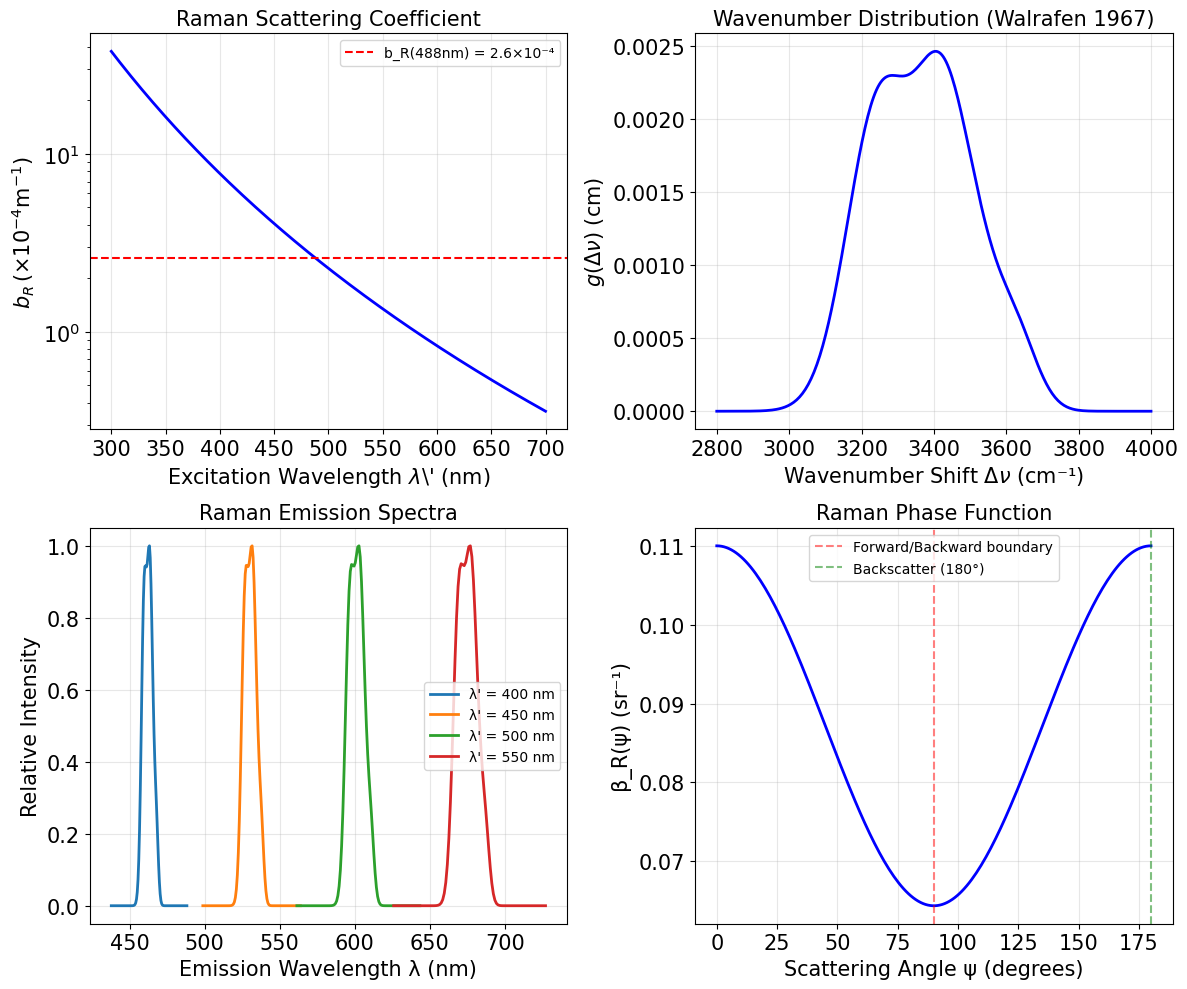

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Scattering coefficient vs wavelength
ax1 = axes[0, 0]
lam = np.linspace(300, 700, 200)
b_R = raman.raman_scattering_coeff(lam)
ax1.semilogy(lam, b_R * 1e4, 'b-', linewidth=2)
ax1.set_xlabel(r'Excitation Wavelength $\lambda$\' (nm)')
ax1.set_ylabel(r'$b_R \, \rm (×10^{-4} m^{-1})$')
ax1.set_title('Raman Scattering Coefficient')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=2.6, color='r', linestyle='--', label='b_R(488nm) = 2.6×10⁻⁴')
ax1.legend()

# Plot 2: Wavenumber distribution function
ax2 = axes[0, 1]
delta_nu = np.linspace(2800, 4000, 300)
g = raman.wavenumber_distribution(delta_nu)
ax2.plot(delta_nu, g, 'b-', linewidth=2)
ax2.set_xlabel(r'Wavenumber Shift $\Delta \nu$ (cm⁻¹)')
ax2.set_ylabel(r'$g(\Delta \nu$) (cm)')
ax2.set_title('Wavenumber Distribution (Walrafen 1967)')
ax2.grid(True, alpha=0.3)

# Plot 3: Emission spectra for different excitation wavelengths
ax3 = axes[1, 0]
for lam_ex in [400, 450, 500, 550]:
    lam_em, intensity = raman.get_emission_spectrum(lam_ex)
    # Normalize for plotting
    intensity_norm = intensity / intensity.max()
    ax3.plot(lam_em, intensity_norm, label=f'λ\' = {lam_ex} nm', linewidth=2)
ax3.set_xlabel('Emission Wavelength λ (nm)')
ax3.set_ylabel('Relative Intensity')
ax3.set_title('Raman Emission Spectra')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Phase function
ax4 = axes[1, 1]
psi = np.linspace(0, np.pi, 180)
psi_deg = np.degrees(psi)
phase = raman.raman_phase_function(psi)
ax4.plot(psi_deg, phase, 'b-', linewidth=2)
ax4.set_xlabel('Scattering Angle ψ (degrees)')
ax4.set_ylabel('β_R(ψ) (sr⁻¹)')
ax4.set_title('Raman Phase Function')
ax4.grid(True, alpha=0.3)
ax4.axvline(x=90, color='r', linestyle='--', alpha=0.5, label='Forward/Backward boundary')
ax4.axvline(x=180, color='g', linestyle='--', alpha=0.5, label='Backscatter (180°)')
ax4.legend()

for ax in [ax1, ax2, ax3, ax4]:
    plotting.set_fontsize(ax, 15)

plt.tight_layout()
plt.show()

## 2. Tests for Raman Scattering Corrections

The following tests verify the Raman correction calculations based on Sathyendranath & Platt (1998).

### 2.1 Raman Backscattering Coefficient Test

In [15]:
def test_raman_backscattering_coeff():
    """Test Raman backscattering coefficient calculation."""
    # Test at reference wavelength (488 nm)
    bb_R_488 = raman.raman_backscattering_coeff(488)
    print(f"b_bR at 488 nm: {bb_R_488:.3e} m⁻¹")
    print(f"Reference value (Hydrolight): {raman.B_RAMAN_488_HYDROLIGHT * 0.5:.3e} m⁻¹")
    
    # Should be close to reference value (half of total scattering)
    assert np.isclose(bb_R_488, raman.B_RAMAN_488_HYDROLIGHT * 0.5, rtol=0.1)
    print("✓ Reference value check passed")

    # Test wavelength dependence (shorter wavelength = higher scattering)
    bb_R_400 = raman.raman_backscattering_coeff(400)
    bb_R_600 = raman.raman_backscattering_coeff(600)
    assert bb_R_400 > bb_R_488 > bb_R_600
    print(f"✓ Wavelength dependence: {bb_R_400:.3e} > {bb_R_488:.3e} > {bb_R_600:.3e}")

    # Test array input
    wavelengths = np.array([400, 450, 500, 550])
    bb_R_arr = raman.raman_backscattering_coeff(wavelengths)
    assert bb_R_arr.shape == (4,)
    assert np.all(np.diff(bb_R_arr) < 0)  # Decreasing with wavelength
    print("✓ Array input test passed")
    
    return True

test_raman_backscattering_coeff()
## JXP adds -- this is the same code in test_raman.py

b_bR at 488 nm: 1.300e-04 m⁻¹
Reference value (Hydrolight): 1.300e-04 m⁻¹
✓ Reference value check passed
✓ Wavelength dependence: 3.881e-04 > 1.300e-04 > 4.173e-05
✓ Array input test passed


True

### 2.2 Elastic Reflectance Test

In [16]:
def test_calc_R_elastic():
    """Test elastic reflectance calculation."""
    a = 0.05   # m^-1
    bb = 0.002  # m^-1

    R_E = rrs.calc_R_elastic(a, bb)
    print(f"Elastic reflectance R_E: {R_E:.4f}")

    # Reflectance should be positive and reasonable (< 0.1 for these values)
    assert R_E > 0
    assert R_E < 0.1
    print("✓ Single value test passed")

    # Test with arrays
    a_arr = np.array([0.03, 0.05, 0.1])
    bb_arr = np.array([0.003, 0.002, 0.001])
    R_E_arr = rrs.calc_R_elastic(a_arr, bb_arr)
    assert R_E_arr.shape == (3,)
    # Higher bb/a ratio should give higher reflectance
    assert R_E_arr[0] > R_E_arr[2]
    print(f"✓ Array test: R_E = {R_E_arr}")
    
    return True

test_calc_R_elastic()

Elastic reflectance R_E: 0.0137
✓ Single value test passed
✓ Array test: R_E = [0.03246753 0.01373626 0.00353607]


True

### 2.3 First-Order Raman Reflectance Test (Eq. 11)

In [17]:
def test_calc_R_raman_first_order():
    """Test first-order Raman reflectance calculation (Eq. 11)."""
    # Emission at 520 nm, excitation at 443 nm
    a_em, bb_em = 0.05, 0.002
    a_ex, bb_ex = 0.03, 0.003
    bb_R = raman.raman_backscattering_coeff(443)

    R_R = rrs.calc_R_raman_first_order(a_em, bb_em, a_ex, bb_ex, bb_R)
    print(f"First-order Raman reflectance R_R: {R_R:.4e}")

    # Should be positive
    assert R_R > 0
    
    # Typically smaller than elastic reflectance but significant
    R_E = rrs.calc_R_elastic(a_em, bb_em)
    print(f"Elastic reflectance R_E: {R_E:.4e}")
    print(f"R_R / R_E ratio: {R_R/R_E:.3f}")
    
    assert R_R < R_E
    assert R_R > 0.001  # Should be non-negligible
    print("✓ First-order Raman test passed")
    
    return True

test_calc_R_raman_first_order()

First-order Raman reflectance R_R: 1.7482e-03
Elastic reflectance R_E: 1.3736e-02
R_R / R_E ratio: 0.127
✓ First-order Raman test passed


True

### 2.4 Second-Order Raman Reflectance Terms (Eqs. 18, 23)

In [18]:
def test_calc_R_raman_second_order():
    """Test second-order Raman reflectance terms (Eqs. 18, 23)."""
    a_em, bb_em = 0.05, 0.002
    a_ex, bb_ex = 0.03, 0.003
    bb_R = raman.raman_backscattering_coeff(443)

    R_R = rrs.calc_R_raman_first_order(a_em, bb_em, a_ex, bb_ex, bb_R)
    R_RE = rrs.calc_R_raman_RE(a_em, bb_em, a_ex, bb_ex, bb_R)
    R_ER = rrs.calc_R_raman_ER(a_em, bb_em, a_ex, bb_ex, bb_R)

    print(f"First-order R_R: {R_R:.4e}")
    print(f"Second-order R_RE: {R_RE:.4e}")
    print(f"Second-order R_ER: {R_ER:.4e}")

    # Second-order terms should be positive
    assert R_RE > 0
    assert R_ER > 0

    # Second-order terms should be much smaller than first-order
    # Paper says ~10% of first-order term
    assert R_RE < 0.2 * R_R
    assert R_ER < 0.2 * R_R

    # Combined second-order should be ~10-20% of first-order
    second_order_ratio = (R_RE + R_ER) / R_R
    print(f"Second-order / First-order ratio: {second_order_ratio:.3f}")
    assert 0.05 < second_order_ratio < 0.25
    print("✓ Second-order Raman test passed")
    
    return True

test_calc_R_raman_second_order()

First-order R_R: 1.7482e-03
Second-order R_RE: 3.3620e-05
Second-order R_ER: 1.0217e-04
Second-order / First-order ratio: 0.078
✓ Second-order Raman test passed


True

### 2.5 Total Raman Reflectance Test

In [19]:
def test_calc_R_raman_total():
    """Test total Raman reflectance calculation."""
    a_em, bb_em = 0.05, 0.002
    a_ex, bb_ex = 0.03, 0.003
    bb_R = raman.raman_backscattering_coeff(443)

    # With second-order terms
    R_total = rrs.calc_R_raman_total(
        a_em, bb_em, a_ex, bb_ex, bb_R, include_second_order=True
    )

    # Without second-order terms
    R_first_only = rrs.calc_R_raman_total(
        a_em, bb_em, a_ex, bb_ex, bb_R, include_second_order=False
    )

    print(f"Total Raman (with 2nd order): {R_total:.4e}")
    print(f"First-order only: {R_first_only:.4e}")
    print(f"Enhancement from 2nd order: {(R_total/R_first_only - 1)*100:.1f}%")

    # Total should be greater than first-order only
    assert R_total > R_first_only

    # Difference should be the second-order contribution
    R_R = rrs.calc_R_raman_first_order(a_em, bb_em, a_ex, bb_ex, bb_R)
    assert np.isclose(R_first_only, R_R)
    print("✓ Total Raman test passed")
    
    return True

test_calc_R_raman_total()

Total Raman (with 2nd order): 1.8840e-03
First-order only: 1.7482e-03
Enhancement from 2nd order: 7.8%
✓ Total Raman test passed


True

### 2.6 Raman Correction Factor Test

In [20]:
def test_calc_raman_correction_factor():
    """Test Raman correction factor calculation."""
    a_em, bb_em = 0.05, 0.002
    a_ex, bb_ex = 0.03, 0.003
    bb_R = raman.raman_backscattering_coeff(443)

    corr = rrs.calc_raman_correction_factor(
        a_em, bb_em, a_ex, bb_ex, bb_R
    )

    print(f"Raman correction factor: {corr:.4f}")

    # Correction factor should be > 1 (Raman adds to reflectance)
    assert corr > 1.0
    # Typically < 1.5 for these conditions
    assert corr < 1.5
    print("✓ Correction factor range test passed")

    # For clearer water, correction should be larger
    a_clear, bb_clear = 0.02, 0.001
    corr_clear = rrs.calc_raman_correction_factor(
        a_clear, bb_clear, a_ex, bb_ex, bb_R
    )
    print(f"Correction factor (clear water): {corr_clear:.4f}")
    assert corr_clear > corr
    print("✓ Clear water test passed")
    
    return True

test_calc_raman_correction_factor()

Raman correction factor: 1.1372
✓ Correction factor range test passed
Correction factor (clear water): 1.1989
✓ Clear water test passed


True

### 2.7 Rrs with Raman Correction Test

In [21]:
def test_calc_Rrs_with_raman():
    """Test Rrs calculation with Raman correction."""
    a_em, bb_em = 0.05, 0.002
    a_ex, bb_ex = 0.03, 0.003
    bb_R = raman.raman_backscattering_coeff(443)

    # Elastic only
    Rrs_elastic = rrs.calc_Rrs(a_em, bb_em)

    # With Raman
    Rrs_with_raman = rrs.calc_Rrs_with_raman(
        a_em, bb_em, a_ex, bb_ex, bb_R
    )

    print(f"Rrs (elastic only): {Rrs_elastic:.4e} sr⁻¹")
    print(f"Rrs (with Raman): {Rrs_with_raman:.4e} sr⁻¹")
    print(f"Enhancement: {(Rrs_with_raman/Rrs_elastic - 1)*100:.1f}%")

    # With Raman should be higher
    assert Rrs_with_raman > Rrs_elastic

    # Both should be positive and reasonable
    assert Rrs_elastic > 0
    assert Rrs_with_raman > 0
    assert Rrs_elastic < 0.1
    assert Rrs_with_raman < 0.1
    print("✓ Rrs with Raman test passed")
    
    return True

test_calc_Rrs_with_raman()

Rrs (elastic only): 1.9717e-03 sr⁻¹
Rrs (with Raman): 2.9545e-03 sr⁻¹
Enhancement: 49.8%
✓ Rrs with Raman test passed


True

### 2.8 Array Calculations Test

In [22]:
def test_array_calculations():
    """Test that all functions work with array inputs."""
    # Multiple wavelengths
    wavelengths_em = np.array([480, 520, 560, 600])
    wavelengths_ex = wavelengths_em - 80  # Approximate excitation wavelengths

    a_em = np.array([0.04, 0.05, 0.07, 0.25])
    bb_em = np.array([0.003, 0.002, 0.0015, 0.001])
    a_ex = np.array([0.025, 0.03, 0.035, 0.04])
    bb_ex = np.array([0.004, 0.003, 0.0025, 0.002])
    bb_R = raman.raman_backscattering_coeff(wavelengths_ex)

    # Test all functions with arrays
    R_E = rrs.calc_R_elastic(a_em, bb_em)
    R_R = rrs.calc_R_raman_first_order(a_em, bb_em, a_ex, bb_ex, bb_R)
    R_RE = rrs.calc_R_raman_RE(a_em, bb_em, a_ex, bb_ex, bb_R)
    R_ER = rrs.calc_R_raman_ER(a_em, bb_em, a_ex, bb_ex, bb_R)
    R_total = rrs.calc_R_raman_total(a_em, bb_em, a_ex, bb_ex, bb_R)
    corr = rrs.calc_raman_correction_factor(a_em, bb_em, a_ex, bb_ex, bb_R)
    Rrs = rrs.calc_Rrs_with_raman(a_em, bb_em, a_ex, bb_ex, bb_R)

    print("Array shapes:")
    print(f"  R_E: {R_E.shape}, R_R: {R_R.shape}")
    print(f"  R_RE: {R_RE.shape}, R_ER: {R_ER.shape}")
    print(f"  R_total: {R_total.shape}, corr: {corr.shape}")
    print(f"  Rrs: {Rrs.shape}")

    # Check shapes
    assert R_E.shape == (4,)
    assert R_R.shape == (4,)
    assert R_RE.shape == (4,)
    assert R_ER.shape == (4,)
    assert R_total.shape == (4,)
    assert corr.shape == (4,)
    assert Rrs.shape == (4,)

    # All values should be positive
    assert np.all(R_E > 0)
    assert np.all(R_R > 0)
    assert np.all(R_RE > 0)
    assert np.all(R_ER > 0)
    assert np.all(R_total > 0)
    assert np.all(corr > 1)
    assert np.all(Rrs > 0)
    print("✓ Array calculations test passed")
    
    return True

test_array_calculations()

Array shapes:
  R_E: (4,), R_R: (4,)
  R_RE: (4,), R_ER: (4,)
  R_total: (4,), corr: (4,)
  Rrs: (4,)
✓ Array calculations test passed


True

### 2.9 Wavelength Dependence Test

In [23]:
def test_wavelength_dependence():
    """Test that Raman contribution is significant in clear water."""
    # Clear water conditions
    # Absorption increases with wavelength (especially red)
    wavelengths = np.array([450, 500, 550, 600])
    a_water = np.array([0.015, 0.026, 0.064, 0.24])  # Approximate pure water absorption
    bb_water = np.array([0.0025, 0.0018, 0.0013, 0.001])  # Pure water backscatter

    # Get excitation wavelengths (~80 nm shorter for ~3400 cm^-1 shift)
    wavelengths_ex = wavelengths - 80
    a_ex = np.interp(wavelengths_ex, wavelengths, a_water)
    bb_ex = np.interp(wavelengths_ex, wavelengths, bb_water)
    bb_R = raman.raman_backscattering_coeff(wavelengths_ex)

    # Calculate correction factors
    corr = rrs.calc_raman_correction_factor(
        a_water, bb_water, a_ex, bb_ex, bb_R
    )

    print("Wavelength dependence of Raman correction (clear water):")
    for i, wl in enumerate(wavelengths):
        print(f"  {wl} nm: correction factor = {corr[i]:.3f}")

    # Correction should be significant (> 1) at all wavelengths
    assert np.all(corr > 1.0)
    print("✓ Wavelength dependence test passed")
    
    return True

test_wavelength_dependence()

Wavelength dependence of Raman correction (clear water):
  450 nm: correction factor = 1.277
  500 nm: correction factor = 1.214
  550 nm: correction factor = 1.174
  600 nm: correction factor = 1.133
✓ Wavelength dependence test passed


True

### 2.10 Downwelling Irradiance Ratio Effect Test

In [24]:
def test_Ed_ratio_effect():
    """Test effect of downwelling irradiance ratio on Raman contribution."""
    a_em, bb_em = 0.05, 0.002
    a_ex, bb_ex = 0.03, 0.003
    bb_R = raman.raman_backscattering_coeff(443)

    # Ed_ratio = 1 (equal irradiance at both wavelengths)
    R_R_1 = rrs.calc_R_raman_first_order(
        a_em, bb_em, a_ex, bb_ex, bb_R, Ed_ratio=1.0
    )

    # Ed_ratio = 1.5 (more irradiance at excitation wavelength)
    R_R_1p5 = rrs.calc_R_raman_first_order(
        a_em, bb_em, a_ex, bb_ex, bb_R, Ed_ratio=1.5
    )

    print(f"R_R with Ed_ratio=1.0: {R_R_1:.4e}")
    print(f"R_R with Ed_ratio=1.5: {R_R_1p5:.4e}")
    print(f"Ratio: {R_R_1p5/R_R_1:.3f}")

    # Higher Ed_ratio should give higher Raman reflectance
    assert R_R_1p5 > R_R_1
    # Should scale linearly with Ed_ratio
    assert np.isclose(R_R_1p5 / R_R_1, 1.5, rtol=0.01)
    print("✓ Ed ratio effect test passed")
    
    return True

test_Ed_ratio_effect()

R_R with Ed_ratio=1.0: 1.7482e-03
R_R with Ed_ratio=1.5: 2.6223e-03
Ratio: 1.500
✓ Ed ratio effect test passed


True

### 2.11 Mean Cosine Sensitivity Test

In [25]:
def test_mean_cosine_sensitivity():
    """Test sensitivity to mean cosine parameters."""
    a_em, bb_em = 0.05, 0.002
    a_ex, bb_ex = 0.03, 0.003
    bb_R = raman.raman_backscattering_coeff(443)

    # Default mean cosines
    R_default = rrs.calc_R_raman_total(
        a_em, bb_em, a_ex, bb_ex, bb_R
    )

    # Higher mu_d (more direct sunlight)
    R_high_mud = rrs.calc_R_raman_total(
        a_em, bb_em, a_ex, bb_ex, bb_R, mu_d=0.95
    )

    # Lower mu_d (more diffuse light)
    R_low_mud = rrs.calc_R_raman_total(
        a_em, bb_em, a_ex, bb_ex, bb_R, mu_d=0.7
    )

    print(f"R_total (default mu_d): {R_default:.4e}")
    print(f"R_total (mu_d=0.95, direct): {R_high_mud:.4e}")
    print(f"R_total (mu_d=0.7, diffuse): {R_low_mud:.4e}")

    # Results should vary with mu_d
    assert R_high_mud != R_default
    assert R_low_mud != R_default
    print("✓ Mean cosine sensitivity test passed")
    
    return True

test_mean_cosine_sensitivity()

R_total (default mu_d): 1.8840e-03
R_total (mu_d=0.95, direct): 1.8116e-03
R_total (mu_d=0.7, diffuse): 2.2431e-03
✓ Mean cosine sensitivity test passed


True

### 2.12 Consistency with Gordon Formula Test

In [26]:
def test_consistency_with_gordon():
    """Test that elastic reflectance is consistent with Gordon formula."""
    a = 0.05
    bb = 0.002

    # Gordon formula Rrs
    Rrs_gordon = rrs.calc_Rrs(a, bb)

    # Our elastic reflectance converted to Rrs
    R_E = rrs.calc_R_elastic(a, bb, mu_d=0.9, mu_u=0.5)

    print(f"Gordon formula Rrs: {Rrs_gordon:.4e} sr⁻¹")
    print(f"Elastic reflectance R_E: {R_E:.4e}")
    print(f"Ratio Rrs_gordon/R_E: {Rrs_gordon/R_E:.3f}")

    # Both should be in the same ballpark (within factor of 2-3)
    # They use different formulations but should give similar magnitude
    assert Rrs_gordon > 0
    assert R_E > 0
    assert 0.1 < Rrs_gordon / R_E < 10  # Order of magnitude check
    print("✓ Gordon formula consistency test passed")
    
    return True

test_consistency_with_gordon()

Gordon formula Rrs: 1.9717e-03 sr⁻¹
Elastic reflectance R_E: 1.3736e-02
Ratio Rrs_gordon/R_E: 0.144
✓ Gordon formula consistency test passed


True

### 2.13 Wavelength Conversion Test

In [27]:
def test_raman_wavelength_conversion():
    """Test excitation/emission wavelength conversion functions."""
    # At 488 nm excitation, emission should be around 583 nm
    lambda_ex = 488
    lambda_em = raman.excitation_to_emission_wavelength(lambda_ex)

    print(f"Excitation wavelength: {lambda_ex} nm")
    print(f"Emission wavelength: {lambda_em:.1f} nm")
    
    # Should be longer wavelength (Stokes shift)
    assert lambda_em > lambda_ex

    # For 3400 cm^-1 shift, expect ~95 nm difference at 488 nm
    shift = lambda_em - lambda_ex
    print(f"Stokes shift: {shift:.1f} nm")
    assert 80 < shift < 110

    # Round-trip conversion should return original
    lambda_ex_back = raman.emission_to_excitation_wavelength(lambda_em)
    print(f"Round-trip excitation: {lambda_ex_back:.1f} nm")
    assert np.isclose(lambda_ex, lambda_ex_back, rtol=0.001)
    print("✓ Wavelength conversion test passed")
    
    return True

test_raman_wavelength_conversion()

Excitation wavelength: 488 nm
Emission wavelength: 585.1 nm
Stokes shift: 97.1 nm
Round-trip excitation: 488.0 nm
✓ Wavelength conversion test passed


True

## 3. Run All Tests

In [28]:
def run_all_tests():
    """Run all Raman scattering tests."""
    tests = [
        ("Raman backscattering coefficient", test_raman_backscattering_coeff),
        ("Elastic reflectance", test_calc_R_elastic),
        ("First-order Raman reflectance", test_calc_R_raman_first_order),
        ("Second-order Raman reflectance", test_calc_R_raman_second_order),
        ("Total Raman reflectance", test_calc_R_raman_total),
        ("Raman correction factor", test_calc_raman_correction_factor),
        ("Rrs with Raman", test_calc_Rrs_with_raman),
        ("Array calculations", test_array_calculations),
        ("Wavelength dependence", test_wavelength_dependence),
        ("Ed ratio effect", test_Ed_ratio_effect),
        ("Mean cosine sensitivity", test_mean_cosine_sensitivity),
        ("Gordon formula consistency", test_consistency_with_gordon),
        ("Wavelength conversion", test_raman_wavelength_conversion),
    ]
    
    print("=" * 60)
    print("Running All Raman Scattering Tests")
    print("=" * 60)
    
    passed = 0
    failed = 0
    
    for name, test_func in tests:
        print(f"\n{'─' * 50}")
        print(f"Test: {name}")
        print("─" * 50)
        try:
            result = test_func()
            if result:
                passed += 1
        except Exception as e:
            print(f"✗ FAILED: {e}")
            failed += 1
    
    print(f"\n{'=' * 60}")
    print(f"Summary: {passed} passed, {failed} failed out of {len(tests)} tests")
    print("=" * 60)

run_all_tests()

Running All Raman Scattering Tests

──────────────────────────────────────────────────
Test: Raman backscattering coefficient
──────────────────────────────────────────────────
b_bR at 488 nm: 1.300e-04 m⁻¹
Reference value (Hydrolight): 1.300e-04 m⁻¹
✓ Reference value check passed
✓ Wavelength dependence: 3.881e-04 > 1.300e-04 > 4.173e-05
✓ Array input test passed

──────────────────────────────────────────────────
Test: Elastic reflectance
──────────────────────────────────────────────────
Elastic reflectance R_E: 0.0137
✓ Single value test passed
✓ Array test: R_E = [0.03246753 0.01373626 0.00353607]

──────────────────────────────────────────────────
Test: First-order Raman reflectance
──────────────────────────────────────────────────
First-order Raman reflectance R_R: 1.7482e-03
Elastic reflectance R_E: 1.3736e-02
R_R / R_E ratio: 0.127
✓ First-order Raman test passed

──────────────────────────────────────────────────
Test: Second-order Raman reflectance
─────────────────────────